<a href="https://colab.research.google.com/github/annaannaR/NOTEBOOKS-FROM-SCHOOL/blob/main/done/MLP3_1_Time_Series_done.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#Importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

#Setting seaborn default theme
sns.set()

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Time Series

Time series forecasting is the use of a model to predict future values based on previously observed values. It can broadly be categorized into the following categories:

*   Classical / Statistical Models — Moving Averages, Exponential Smoothing,
ARIMA, SARIMA, TBATS
*   Machine Learning — Linear Regression, XGBoost, Random Forest, or any ML model with reduction methods
* Deep Learning — RNN, LSTM


Time series are widely used for non-stationary data, like economic, weather, stock price, and retail sales (which we will use in this assignment).

## Dataset
We are using Superstore sales data that can be found in the [dataset-folder](https://drive.google.com/drive/folders/1jgzUGTqbtGuR1NkrtG1vT5edDgES32Id?usp=sharing). Please download the dataset, and upload to your drive.

There are several categories in the Superstore sales data, but we are going to use/predict the furniture sales.

In [9]:
df = pd.read_excel("/content/Sample-Superstore.xlsx")
furniture = df.loc[df['Category'] == 'Furniture']

In [10]:
# Check the date-range
furniture['Order Date'].min(), furniture['Order Date'].max()

(Timestamp('2014-01-06 00:00:00'), Timestamp('2017-12-30 00:00:00'))

We see we have over 4 years of furniture sales data.

In [11]:
furniture.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


## Data preprocessing

For the sake of training our first Time Series model, we are only going to use the date-column and the corresponding furniture sales. The other columns we will drop.

In [12]:
furniture = furniture[['Order Date','Sales']].sort_values('Order Date')

In [13]:
# Check for missing values
furniture.isnull().sum()

,0
Order Date,0
Sales,0


In [14]:
furniture.head(10)

,Order Date,Sales
1577,2014-01-06,2573.820
1626,2014-01-07,76.728
181,2014-01-10,51.940
150,2014-01-11,9.940
631,2014-01-13,545.940
1024,2014-01-13,333.999
1355,2014-01-14,61.960
200,2014-01-16,127.104
1131,2014-01-19,181.470
1326,2014-01-20,272.940


We see we can have several sales on one date. We are only interested in the total sales on a given day, so we sum these values.

In [15]:
furniture = furniture.groupby('Order Date')['Sales'].sum().reset_index()

Set the index to the date column:

In [16]:
furniture = furniture.set_index('Order Date')
furniture.index

DatetimeIndex(['2014-01-06', '2014-01-07', '2014-01-10', '2014-01-11',
               '2014-01-13', '2014-01-14', '2014-01-16', '2014-01-19',
               '2014-01-20', '2014-01-21',
               ...
               '2017-12-18', '2017-12-19', '2017-12-21', '2017-12-22',
               '2017-12-23', '2017-12-24', '2017-12-25', '2017-12-28',
               '2017-12-29', '2017-12-30'],
              dtype='datetime64[ns]', name='Order Date', length=889, freq=None)

## Visualising

Now that we have selected the right data and made sure it is in the right format, let's take a look at it by visualising it in a Matplotlib-plot.

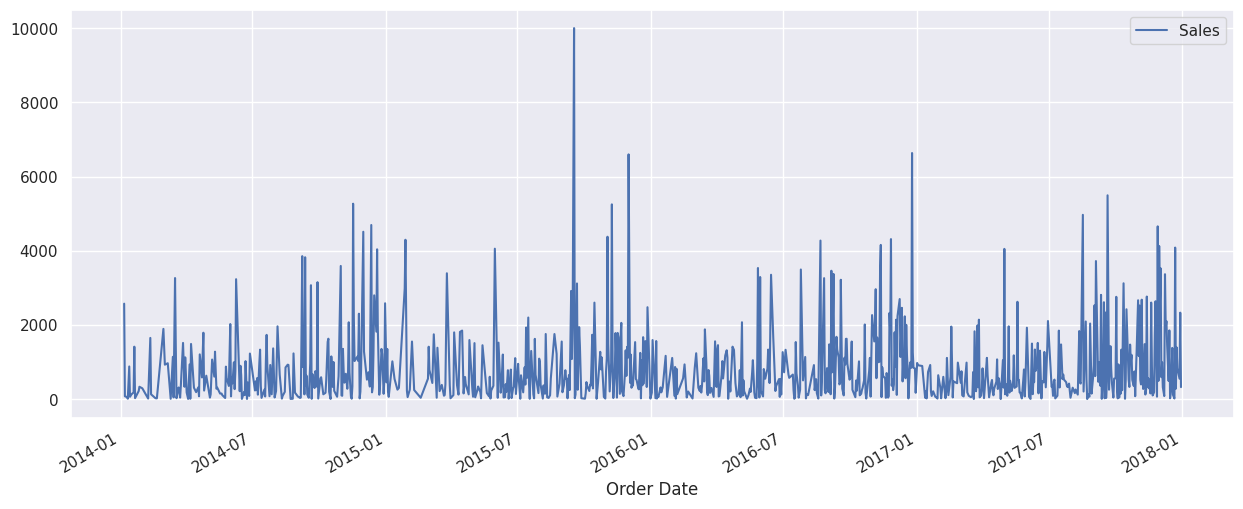

In [17]:
furniture.plot(figsize=(15, 6))
plt.show()

This looks complicated, since there are a lot of values, and no clear trend or seasonality.

Instead of looking at the sales of each individual day, let's model the average daily sales of a month (using the start of each month as the timestamp).

In [18]:
data = furniture['Sales'].resample('MS').mean()

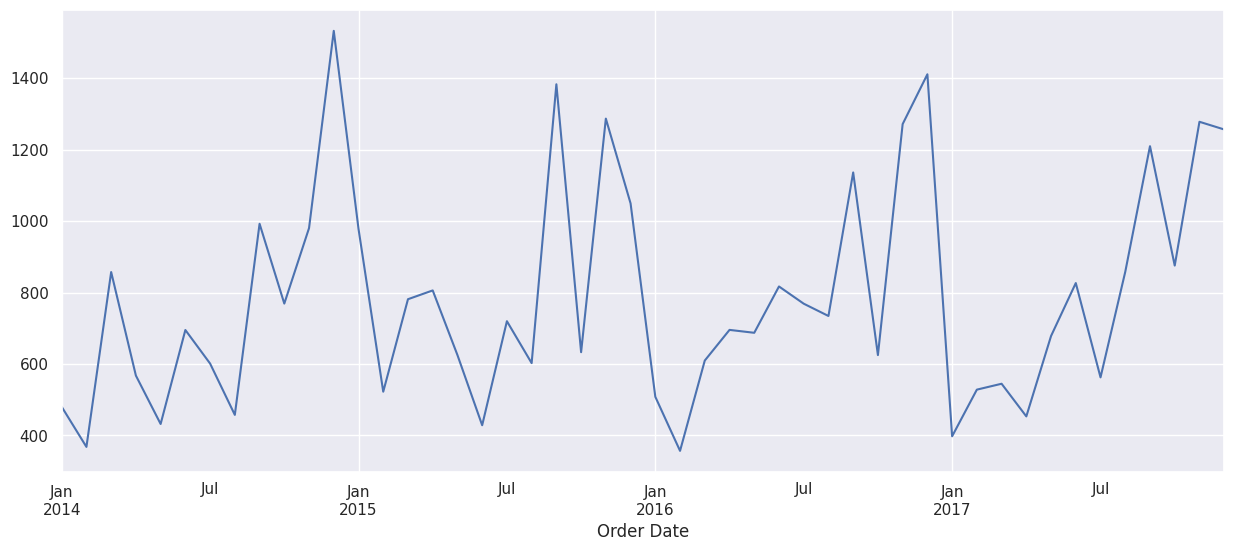

In [19]:
# Plot result
data.plot(figsize=(15, 6))
plt.show()

This already looks a lot cleaner, better suited for our first time creating a Time Series model.

When looking at the plot, we can already see some patterns. Such as sales are always low at the beginning of the year and higher at the end of the year.

We can also visualize our data using a method called time-series decomposition that allows us to decompose our time series into three distinct components: trend, seasonality, and noise.

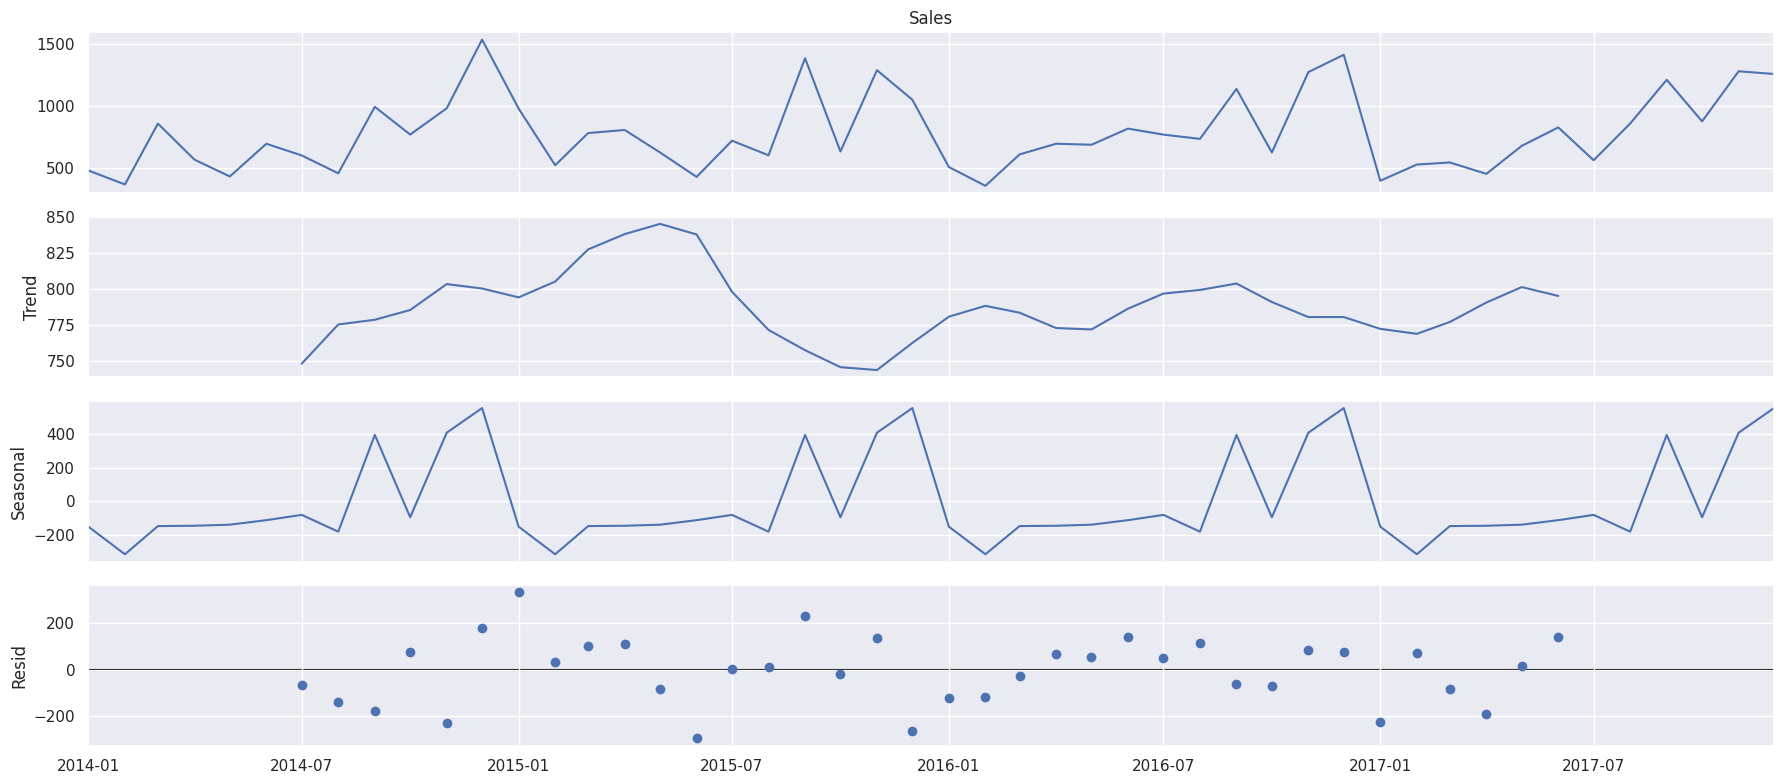

In [20]:
from pylab import rcParams
import statsmodels.api as sm

rcParams['figure.figsize'] = 18, 8
decomposition = sm.tsa.seasonal_decompose(data, model='additive')
fig = decomposition.plot()
plt.show()

We indeed see some seasonality patterns here, but no clear trend.

## Modeling - ARIMA

We are going to apply one of the most commonly used method for time-series forecasting, known as ARIMA, which stands for Autoregressive Integrated Moving Average.

Simplified, the different parts of the model do this:
* Auto Regressive (AR) models are a specific type of regression model where, the dependent variable depends on past values of itself
* Integrated (I)(though it has little to do with integration). It just means that, instead of predicting the time series itself we will predict the differences of the series from one time step to the next time step.
* Moving Average (MA) models work by analysing how wrong you were in predicting values for the previous time-periods to make a better estimate for the current time-period.

These three models work together to create the best possible model.

They come together in ARIMA(p, d, q) where,
* p = number of prior lag observations we include in the model (from AR part)
* d = order of differencing, i.e. a single phase of differencing (from I part)
* q = size of moving average window (from MA part)

### Training

We are going to set these parameters and train our furniture’s sales ARIMA Time Series Model.

An additional parameter we will use is M, which brings a seasonal component to the model.
M indicates the periodicity, i.e. the number of periods in season, such as 12 for monthly data (which is also a good number for our data, which has a clear pattern each year).

Let's take an order of 1 for the first three parameters: include 1 prior observation, difference over 1 prior observation and have a moving average window of 1 observation.
For the seasonal order we will use the same parameters, only no moving average window, and use an M of 12.

(NB: An ideal way of setting these parameters would be to do a grid-search.)

In [21]:
# Initialize the model
mod = sm.tsa.statespace.SARIMAX(data,
                                order=(1, 1, 1), #(p,d,q)
                                seasonal_order=(1, 1, 0, 12)) #(p,d,q,M)

In [22]:
# Train the model
results = mod.fit()

## Testing

To help us understand the accuracy of our forecasts, we compare predicted sales to the real sales of the time series. We set forecasts to start at 2017–01–01.

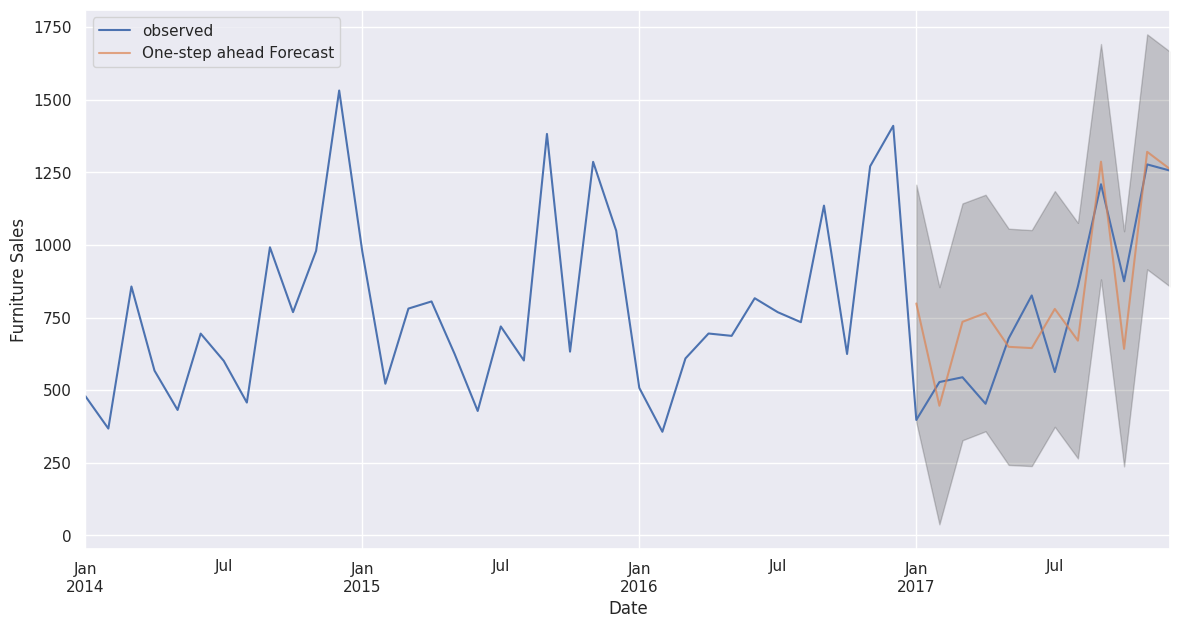

In [23]:
# Predict from 2017
pred = results.get_prediction(start=pd.to_datetime('2017-01-01'), dynamic=False)
pred_ci = pred.conf_int() #confidence interval

# Create result-plot
ax = data['2014':].plot(label='observed')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7, figsize=(14, 7))
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')
plt.legend()
plt.show()

The line plot is showing the observed values compared to the rolling forecast predictions. Overall, our forecasts align with the true values quite well, showing the lower sales at the start of the year, and the higher sales at the end of the year.

## Predicting

With our trained model, we can now predict beyond the scope of our data. This is easily done, using the .get_forecast() function, giving it the number of steps to forecast as a parameter.

In [24]:
# Make predictions for next 100 steps
pred = results.get_forecast(steps=100)
pred_ci = pred.conf_int() #confidence interval

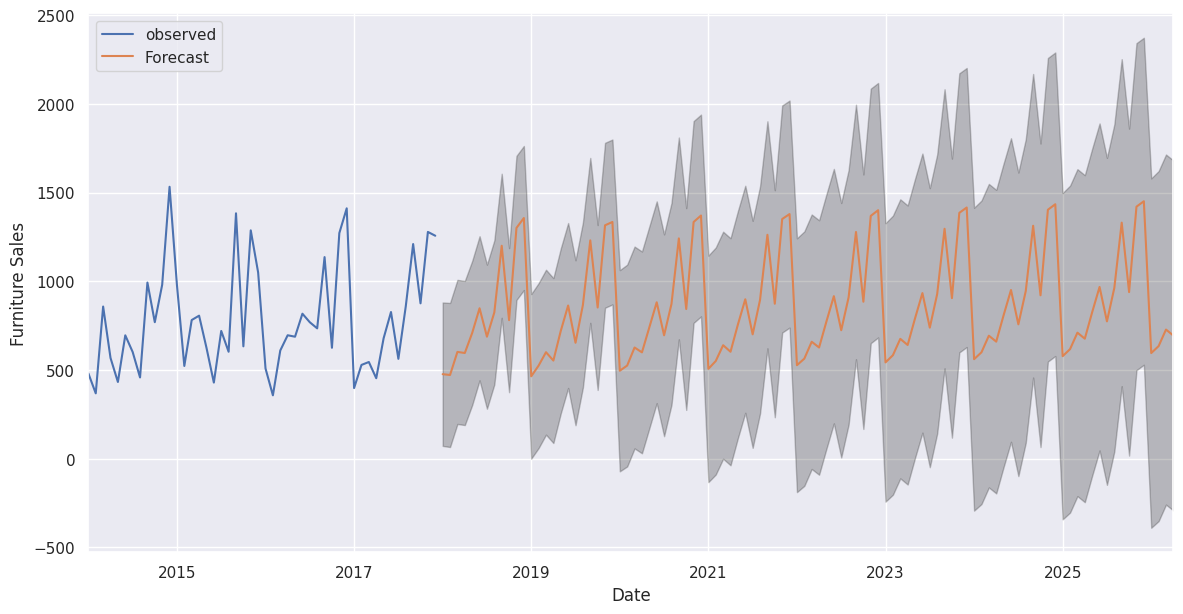

In [26]:
# Plot the predictions
ax = data.plot(label='observed', figsize=(14, 7))
pred.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')
plt.legend()
plt.show()

We clearly see the furniture sales seasonality. And as we get further into the future, the model becomes less confident of it's predictions (see the grey area of the confidence intervals).

## Assignment 3.1

**Question 1**

Now try it yourself, using the same dataset, but selecting another sales category, like 'Office Supplies'.

*   Check the data for missing values, and aggregate if necessary
*   Explore the data
*   You might also want to use daily average sales
*   Train and test your model
*   Predict future values and visualize the results



In [27]:
df_a = pd.read_excel("Sample-Superstore.xlsx")
office = df_a.loc[df_a['Category'] == 'Office Supplies']

In [28]:
office.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2121,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
2122,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
2123,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656
2124,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,0.2,5.7825
2125,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.900,5,0.0,34.4700


In [29]:
office.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6026 entries, 2121 to 8146
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         6026 non-null   int64         
 1   Order ID       6026 non-null   object        
 2   Order Date     6026 non-null   datetime64[ns]
 3   Ship Date      6026 non-null   datetime64[ns]
 4   Ship Mode      6026 non-null   object        
 5   Customer ID    6026 non-null   object        
 6   Customer Name  6026 non-null   object        
 7   Segment        6026 non-null   object        
 8   Country        6026 non-null   object        
 9   City           6026 non-null   object        
 10  State          6026 non-null   object        
 11  Postal Code    6026 non-null   int64         
 12  Region         6026 non-null   object        
 13  Product ID     6026 non-null   object        
 14  Category       6026 non-null   object        
 15  Sub-Category   6026 non

In [37]:
office_sorted=office[['Order Date', 'Sales']].sort_values('Order Date')

In [38]:
office_sorted

,Order Date,Sales
6949,2014-01-03,16.448
2559,2014-01-04,272.736
2558,2014-01-04,11.784
2560,2014-01-04,3.540
3192,2014-01-05,19.536
...,...,...
5227,2017-12-30,3.024
2909,2017-12-30,20.720
2666,2017-12-30,52.776
2908,2017-12-30,13.904


In [39]:
office_final = office_sorted.groupby('Order Date')['Sales'].sum().reset_index()

In [40]:
office_final

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,685.340
4,2014-01-07,10.430
...,...,...
1143,2017-12-26,814.594
1144,2017-12-27,13.248
1145,2017-12-28,1091.244
1146,2017-12-29,282.440


In [41]:
office_final.set_index('Order Date', inplace = True)

In [42]:
office_final

,Sales
Order Date,
2014-01-03,16.448
2014-01-04,288.060
2014-01-05,19.536
2014-01-06,685.340
2014-01-07,10.430
...,...
2017-12-26,814.594
2017-12-27,13.248
2017-12-28,1091.244


<Axes: xlabel='Order Date', ylabel='Sales'>

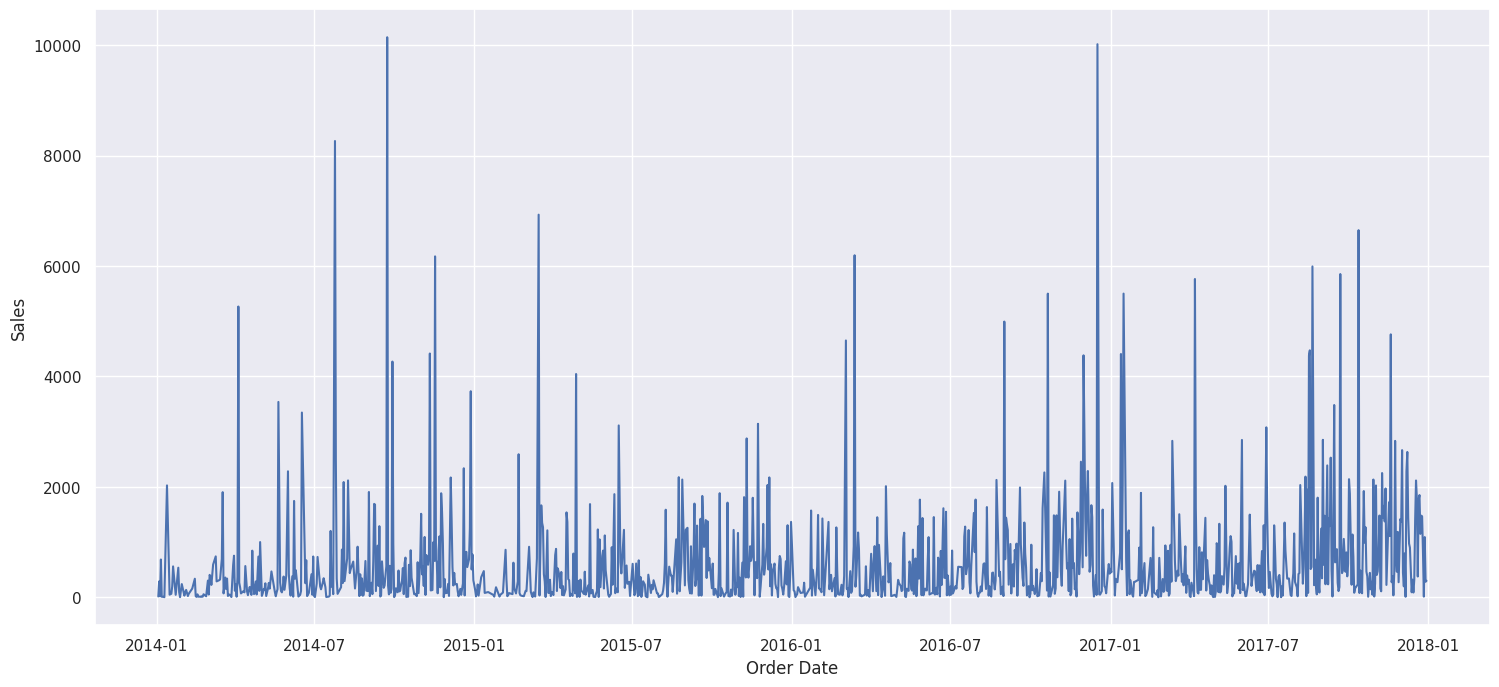

In [43]:
sns.lineplot(office_final, x='Order Date', y = 'Sales')

<Axes: xlabel='Order Date'>

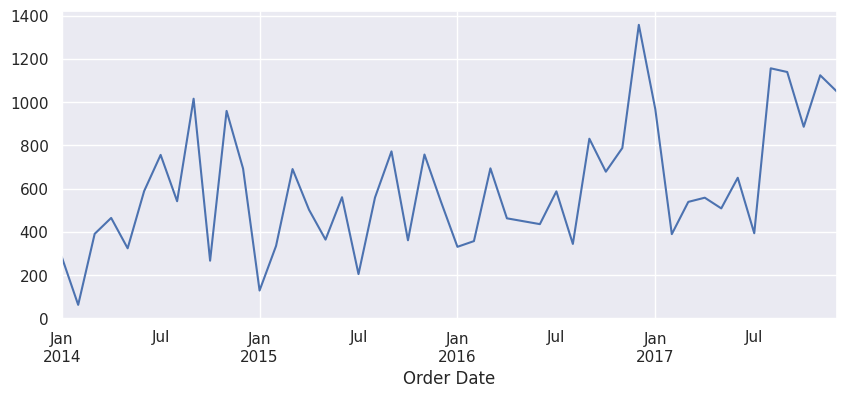

In [44]:
office_by_month = office_final['Sales'].resample('MS').mean()
office_by_month.plot(figsize=(10,4))

<Axes: xlabel='Order Date'>

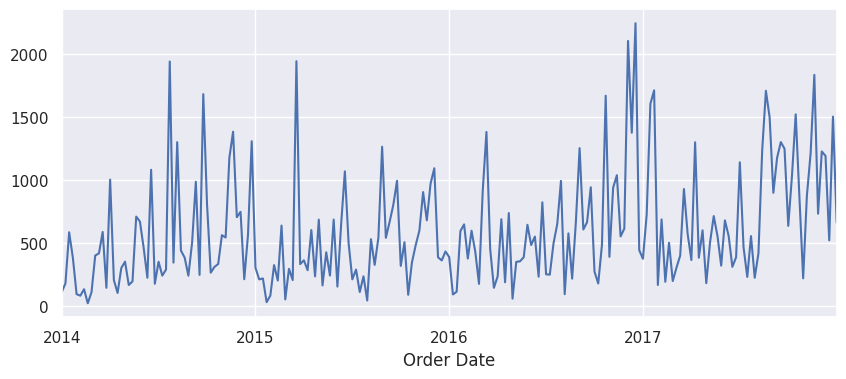

In [45]:
office_by_week = office_final['Sales'].resample('W').mean()
office_by_week.plot(figsize=(10,4))

<Axes: xlabel='Order Date'>

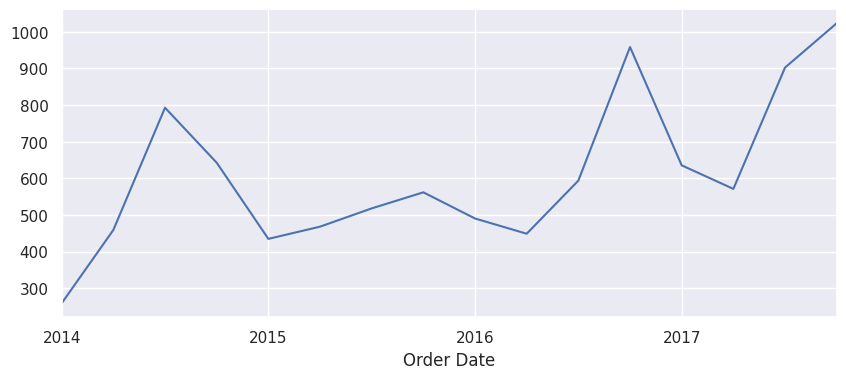

In [46]:
office_by_q = office_final['Sales'].resample('QE').mean()
office_by_q.plot(figsize=(10,4))

In [47]:
decomposition = sm.tsa.seasonal_decompose(office_by_month, model='additive')

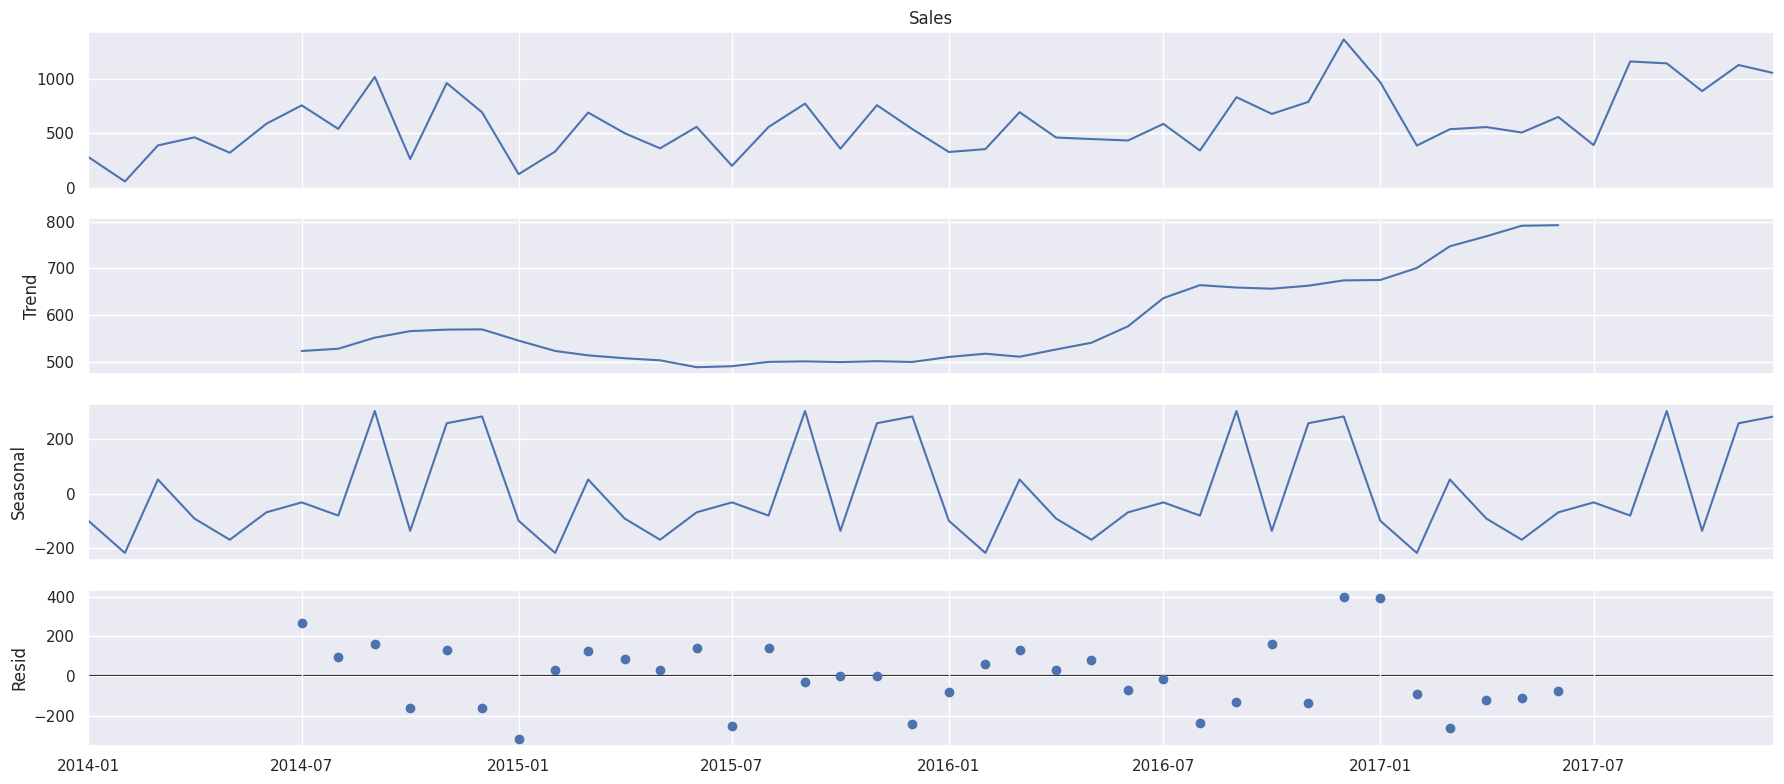

In [48]:
de = decomposition.plot()
plt.show()